# 09_聚类算法-层次聚类

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


本文咱们从层次聚类的概念、详细的推理以及一个非常详细的案例和大家一起分享\~

当你有一组学生数据，想根据他们的成绩和兴趣爱好进行分组。层次聚类会先将每个学生单独放在一个组里，然后根据他们的成绩和兴趣爱好之间的相似度，逐步将最相似的学生合并到同一个组里，最终形成若干个学生组。

首先，层次聚类是一种常用的聚类方法，用于将数据分成不同的组或簇。

这个方法的核心思想是：**根据数据之间的相似度来构建一个“层次结构”，逐步将数据进行合并或拆分，直到得到最终的聚类结果。**

下面，看看基本的步骤：

1. **起点**：开始时，把每一个数据点当作一个独立的簇，每个簇里面只有一个数据点。
2. **计算相似度**：计算每对簇之间的相似度或距离。相似度可以通过各种方法计算，比如欧几里得距离、曼哈顿距离等。
3. **合并最近的簇**：找到距离最近的两个簇，把它们合并成一个新的簇。
4. **更新相似度矩阵**：更新簇之间的相似度或距离，因为合并了新的簇，所以需要重新计算新簇与其他簇之间的相似度。
5. **重复步骤3和4**：不断重复合并最近的簇，直到所有数据点最终合并成一个大簇，或者达到预定的停止条件（比如得到指定数量的簇）。

层次聚类主要分为两种类型：

1. **自底向上（凝聚层次聚类）**：从每个数据点开始，每一步合并两个最相似的簇，直到所有数据点被合并到一个簇中。
2. **自顶向下（分裂层次聚类）**：从所有数据点开始，每一步拆分一个簇成两个最不相似的簇，直到每个数据点成为一个独立的簇。

## 理论基础

层次聚类是一种无监督学习方法，其目的是**根据数据点之间的相似性将数据划分成层次结构的簇。**

### 基本概念

**距离度量**：计算数据点之间的相似性，常用的度量有欧几里得距离、曼哈顿距离等。

对于两个数据点 $x_i$和 $x_j$，欧几里得距离为：


$$
d(x_i, x_j) = \sqrt{\sum_{k=1}^p (x_{ik} - x_{jk})^2}
$$


其中， $p$是数据的维度。

**簇之间的距离**：常用的簇间距离度量方法有单链法、全链法、平均链法和中心点法等。

- **单链法（最小距离）**：$d(A, B) = \min \{ d(x_i, x_j) : x_i \in A, x_j \in B \}$
- **全链法（最大距离）**：$d(A, B) = \max \{ d(x_i, x_j) : x_i \in A, x_j \in B \}$
- **平均链法（平均距离）**：$d(A, B) = \frac{1}{|A||B|} \sum_{x_i \in A} \sum_{x_j \in B} d(x_i, x_j)$
- **中心点法（簇中心距离）**：$d(A, B) = d(\bar{x}_A, \bar{x}_B)$  
其中， $\bar{x}_A$和 $\bar{x}_B$分别是簇 $A$和 $B$的中心点。

### 算法流程

层次聚类的过程可以分为自底向上（凝聚层次聚类）和自顶向下（分裂层次聚类）两种。

下面，咱们主要介绍凝聚层次聚类的算法流程。

1. **初始化**：将每个数据点视为一个独立的簇，形成 $n$个簇， $C = \{C_1, C_2, \ldots, C_n\}$。
2. **计算距离矩阵**：计算所有簇之间的距离，形成距离矩阵 $D$，其中 $D_{ij}$表示簇 $C_i$和 $C_j$之间的距离。
3. **合并最近的簇**：

   - 找到距离最近的两个簇 $C_i$和 $C_j$，即找到 $i, j$使得 $D_{ij} = \min \{ D_{kl} : k \neq l \}$。
   - 合并 $C_i$和 $C_j$成为一个新的簇 $C_{new}$，更新簇集合 $C$。
4. **更新距离矩阵**：计算新簇 $C_{new}$与其他所有簇之间的距离，更新距离矩阵 $D$。$D_{new, k} = \min \{ D_{ik}, D_{jk} \}$；$D_{new, k} = \max \{ D_{ik}, D_{jk} \}$；$D_{new, k} = \frac{|C_i| \cdot D_{ik} + |C_j| \cdot D_{jk}}{|C_i| + |C_j|}$；$\bar{x}_{new} = \frac{|C_i| \cdot \bar{x}_i + |C_j| \cdot \bar{x}_j}{|C_i| + |C_j|}$

   - 对于单链法，更新公式为：

   - 对于全链法，更新公式为：

   - 对于平均链法，更新公式为：

   - 对于中心点法，更新公式为：

   - 然后计算 $\bar{x}_{new}$与其他簇中心点的距离。
5. **重复步骤3和4**：重复合并最近的簇并更新距离矩阵的过程，直到簇的数量减少到预定的值 $k$，或者所有数据点合并成一个簇。

#### 数学推理

为了保证层次聚类算法能够有效地进行，需要证明以下几点：

1. **距离矩阵的对称性**：距离矩阵 $D$是对称的，即 $D_{ij} = D_{ji}$。这是因为距离度量满足对称性。
2. **距离的非负性**：距离矩阵 $D$中的所有值都是非负的，即 $D_{ij} \geq 0$。这是因为距离度量满足非负性。
3. **合并操作的单调性**：每次合并操作后，新簇的距离不会小于之前的最小距离。以单链法为例，合并操作后的新簇与其他簇之间的距离为：  
$D_{new, k} = \min \{ D_{ik}, D_{jk} \}$  
因此，新簇的距离不会比原来的最小距离更小。

通过以上数学推理和算法流程，层次聚类算法能够有效地将数据点分成层次结构的簇，可以帮助大家理解数据的内在结构和分布。

## 代码案例

下面的案例，咱们使用一个真实的数据集，大家可以直接使用api获取。

使用来自 UCI 机器学习库的“葡萄酒数据集”（Wine Dataset），该数据集包含了 178 种葡萄酒的 13 个化学特征，目标是通过层次聚类来分析这些葡萄酒的分组情况。

我们将包括以下步骤：

1. 数据集导入和预处理
2. 使用层次聚类进行聚类分析
3. 聚类结果的可视化
4. 算法优化

**1. 数据集导入和预处理**

首先，我们需要导入数据集并做一定的预处理。

In [2]:
import pandas as pd
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# 加载数据集
data = load_wine()
df = pd.DataFrame(data.data, columns=data.feature_names)

# 数据标准化
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

**2. 使用层次聚类进行聚类分析**

我们使用 `scipy` 库中的 `linkage` 和 `dendrogram` 函数进行层次聚类分析，并绘制树状图。

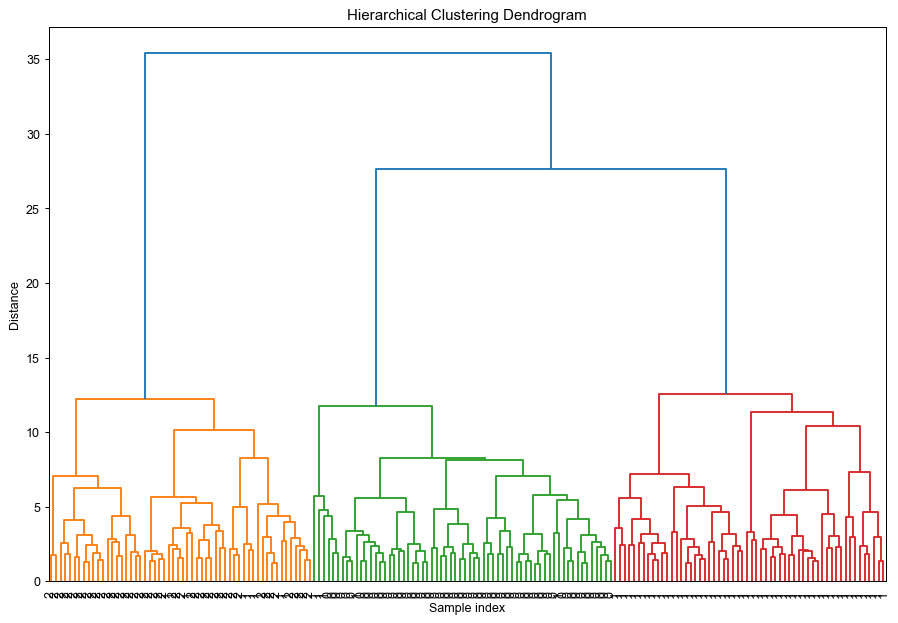

In [3]:
from scipy.cluster.hierarchy import linkage, dendrogram

# 使用欧几里得距离和沃德方法进行层次聚类
Z = linkage(df_scaled, method='ward')

# 绘制树状图
plt.figure(figsize=(12, 8))
dendrogram(Z, labels=data.target, leaf_rotation=90, leaf_font_size=10)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample index')
plt.ylabel('Distance')
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_001.png)

**3. 聚类结果的可视化**

为了更好地理解聚类结果，我们可以将数据降维至二维，并用不同的颜色表示不同的簇。

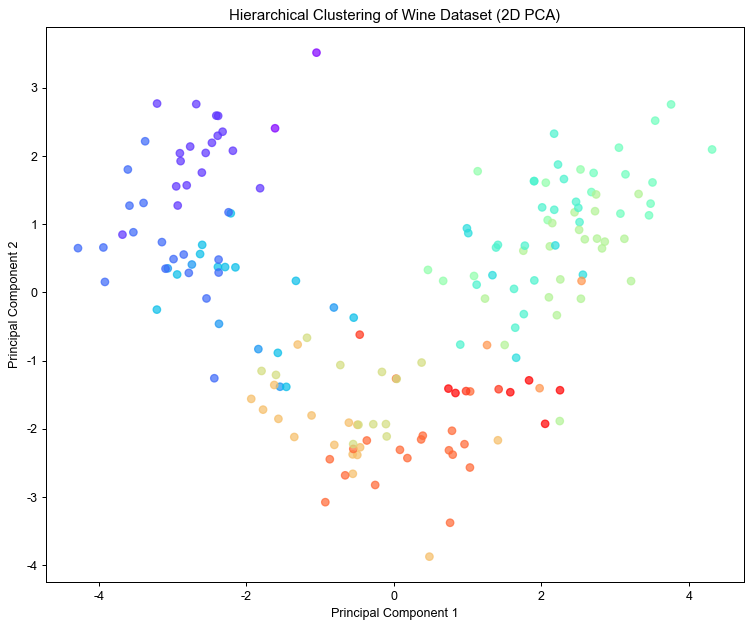

In [4]:
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import fcluster

# 使用PCA将数据降维到二维
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)

# 从树状图中选择一个合适的阈值，划分簇
max_d = 7.0  # 这个阈值需要根据树状图手动调整
clusters = fcluster(Z, max_d, criterion='distance')

# 绘制二维降维后的聚类结果
plt.figure(figsize=(10, 8))
plt.scatter(df_pca[:, 0], df_pca[:, 1], c=clusters, cmap='rainbow', alpha=0.7)
plt.title('Hierarchical Clustering of Wine Dataset (2D PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_002.png)

**4. 算法优化**

我们可以通过调整距离度量方法、合并策略等来优化算法。这里我们展示如何使用不同的合并策略进行层次聚类。

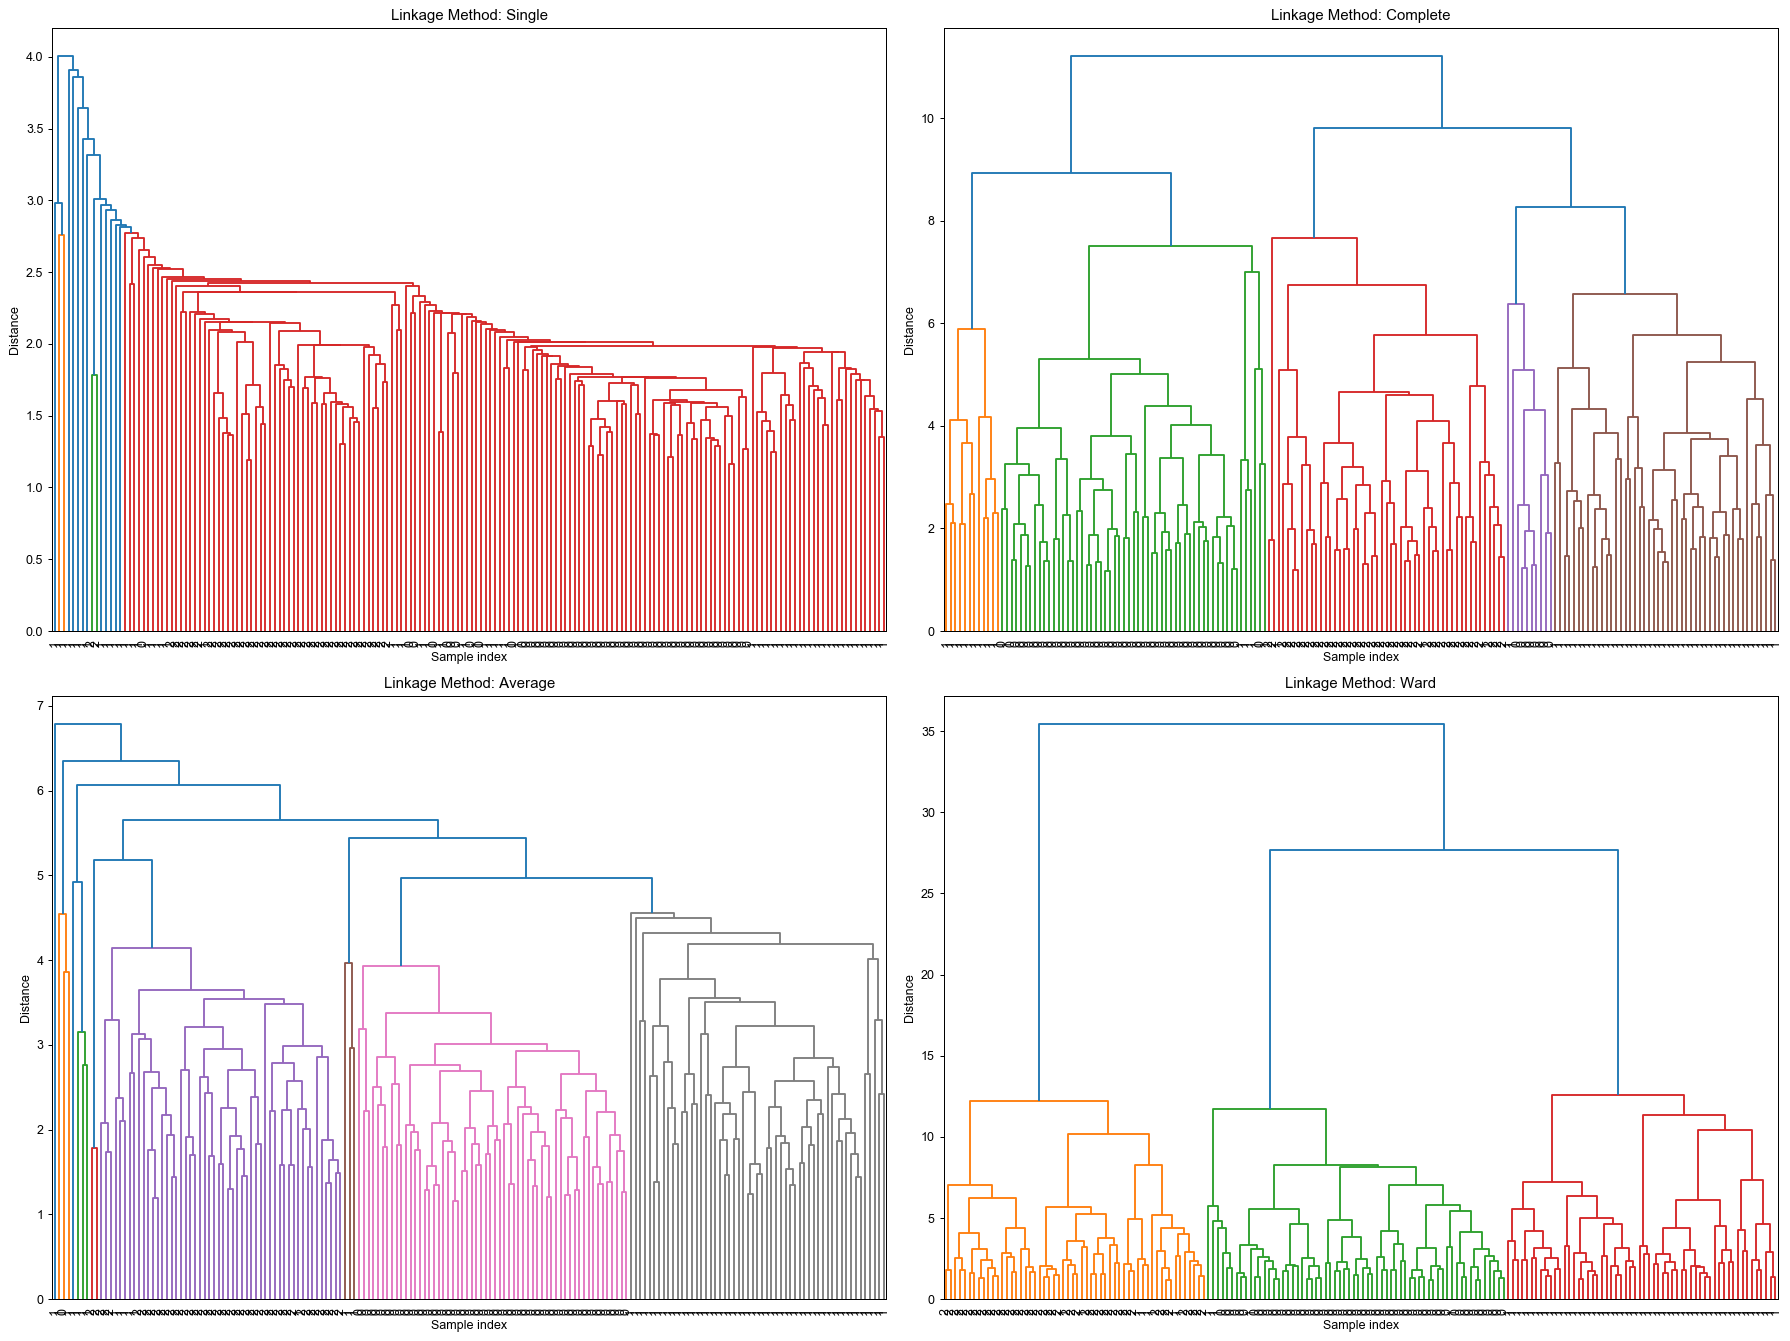

In [5]:
# 使用不同的合并策略进行层次聚类
methods = ['single', 'complete', 'average', 'ward']
plt.figure(figsize=(20, 15))

for i, method in enumerate(methods, 1):
    Z = linkage(df_scaled, method=method)
    plt.subplot(2, 2, i)
    dendrogram(Z, labels=data.target, leaf_rotation=90, leaf_font_size=10)
    plt.title(f'Linkage Method: {method.capitalize()}')
    plt.xlabel('Sample index')
    plt.ylabel('Distance')

plt.tight_layout()
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_003.png)

通过比较不同的合并策略的树状图，我们可以选择最适合当前数据集的策略。

总结如下：

1. **数据标准化**：在聚类前标准化数据有助于消除不同特征量纲之间的影响。
2. **降维**：使用PCA将数据降维至二维，有助于可视化和理解高维数据的聚类结果。
3. **树状图（Dendrogram）**：通过观察树状图，可以确定合适的阈值来划分簇。
4. **合并策略比较**：通过比较不同的合并策略，可以选择最适合的数据集的策略，提高聚类效果。

整个的这些步骤展示了如何使用层次聚类进行数据分析，大家可以通过可视化和算法优化提升结果的理解和效果。

## 模型分析

### 层次聚类模型的优缺点

#### 优点

1. **直观易懂**：层次聚类生成的树状图（dendrogram）可以清晰地展示数据的层次结构，直观且易于理解。
2. **无需预先指定簇的数量**：与K均值聚类不同，层次聚类不需要预先指定簇的数量，适合于不确定簇数的情况。
3. **适用于任意形状的簇**：层次聚类可以处理形状复杂的簇，而K均值聚类更适合球形簇。
4. **数据处理能力**：层次聚类能处理小到中等规模的数据集，适用于一些小样本但高维的数据集。

#### 缺点

1. **计算复杂度高**：层次聚类的计算复杂度较高，通常为 $O(n^3)$，对大规模数据集不太适用。
2. **对噪声和离群点敏感**：噪声和离群点可能会影响聚类结果，导致聚类质量下降。
3. **一旦合并无法撤销**：层次聚类一旦合并两个簇，无法进行拆分，容易在早期步骤中产生错误。

### 适用场景

#### 层次聚类的优选场景

1. **数据规模适中**：适用于小到中等规模的数据集，数据点数量在几百到几千之间。
2. **簇数不确定**：适用于不确定簇的数量，需要通过观察树状图来确定聚类结构。
3. **数据结构层次化**：适用于数据具有明显的层次结构的场景，如生物分类、社会网络分析等。

#### 其他算法的优选场景

1. **大规模数据集**：对于大规模数据集，K均值聚类和MiniBatch K均值聚类更为适用，因为它们计算速度快且效率高。
2. **复杂形状的簇**：当数据集中的簇形状复杂且包含噪声点时，DBSCAN算法更为适用，因为它能够识别任意形状的簇并自动处理噪声点。
3. **高维数据集**：对于高维数据集，谱聚类（Spectral Clustering）可能更为适用，因为它通过图论方法处理数据，能更好地捕捉高维空间中的数据结构。

## 最后

层次聚类在处理中小规模且具有层次结构的数据集时非常有效，特别是当不确定簇的数量时。然而，在大规模数据集或具有复杂形状簇的情况下，其他算法如K均值聚类或DBSCAN可能更为适用。